In [ ]:
import os
import warnings

# Suppress TensorFlow and C++ absl logging (removes the W0000 and INFO logs)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['GLOG_minloglevel'] = '2'

# Suppress the specific Protobuf deprecation warning
warnings.filterwarnings("ignore", category=UserWarning, module="google.protobuf.symbol_database")

import cv2
import mediapipe as mp
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import math
from dataclasses import dataclass
from typing import Optional, Tuple

In [ ]:
# Example usage:
input_video = 'badminton-smash-1.mp4'
output_video = 'badminton-smash-1_analyzed.mp4'

# To check the injury risk logic (Step 3 of your pipeline):
# max_deceleration = np.min(accelerations) # Minimum value represents peak negative acceleration (braking)
# print(f"Peak Shoulder Deceleration: {max_deceleration} deg/s^2")

Aim:

* [x] Display speeds
* [ ] Display a detail assessment table at bottom-right of the screen during each smash
  Smash 1

  | Feature   | Result       | Risk    |
  |-----------|--------------|---------|
  | P-D Seq   | ✓            | 🟢 Low  |
  | V-Amp     | ✗            | 🟡 Mod  |
  | UA Decel  | 6.2k / 3.0k  | 🔴 High |
* [ ] Display a summary table at bottom-right of the screen after all smashes

  | # | Time          | Risk    |
  |---|---------------|---------|
  | 1 | 02:25 - 02:26 | 🟢 Low  |
  | 2 | 03:10 - 03:11 | 🔴 High |


## Kinematic Metrics Extraction

In [55]:
@dataclass
class FrameMetrics:
    trunk_speed: float = 0.0
    trunk_v: Tuple[float, float] = (0.0, 0.0) # (vx, vy)
    shoulder_speed: float = 0.0
    shoulder_v: Tuple[float, float] = (0.0, 0.0)
    elbow_speed: float = 0.0
    elbow_v: Tuple[float, float] = (0.0, 0.0)
    wrist_speed: float = 0.0
    wrist_v: Tuple[float, float] = (0.0, 0.0)
    grip_speed: float = 0.0
    grip_v: Tuple[float, float] = (0.0, 0.0)

    upper_arm_angular_speed: float = 0.0
    upper_arm_angular_deceleration: float = 0.0

    trunk_coord: Optional[Tuple[int, int]] = None
    shoulder_coord: Optional[Tuple[int, int]] = None
    elbow_coord: Optional[Tuple[int, int]] = None
    wrist_coord: Optional[Tuple[int, int]] = None
    grip_coord: Optional[Tuple[int, int]] = None
    head_coord: Optional[Tuple[int, int]] = None

def calculate_angle(a, b, c):
    """Calculates the interior angle (in degrees) at vertex b formed by points a, b, and c."""
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    if angle > 180.0:
        angle = 360.0 - angle
    return angle

def extract_kinematic_metrics(
        input_video_path: str,
        trunk_lm: mp.solutions.pose.PoseLandmark = mp.solutions.pose.PoseLandmark.RIGHT_HIP,
        shoulder_lm: mp.solutions.pose.PoseLandmark = mp.solutions.pose.PoseLandmark.RIGHT_SHOULDER,
        elbow_lm: mp.solutions.pose.PoseLandmark = mp.solutions.pose.PoseLandmark.RIGHT_ELBOW,
        wrist_lm: mp.solutions.pose.PoseLandmark = mp.solutions.pose.PoseLandmark.RIGHT_WRIST,
        grip_lm: mp.solutions.pose.PoseLandmark = mp.solutions.pose.PoseLandmark.RIGHT_INDEX,
        head_lm: mp.solutions.pose.PoseLandmark = mp.solutions.pose.PoseLandmark.NOSE,
        alpha: float = 0.35) -> tuple[list[FrameMetrics], float]:

    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video file: {input_video_path}")

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    if fps <= 0:
        fps = 120

    dt = 1.0 / fps
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    pose = mp.solutions.pose.Pose(
        static_image_mode=False,
        model_complexity=1, # 1 for high-speed motion robustness
        smooth_landmarks=True,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    metrics = []

    trunk_state     = {"prev_pos": None, "vx": 0.0, "vy": 0.0}
    shoulder_state  = {"prev_pos": None, "vx": 0.0, "vy": 0.0}
    elbow_state     = {"prev_pos": None, "vx": 0.0, "vy": 0.0, "prev_angle": None, "omega": 0.0, "prev_omega": 0.0, "ang_accel": 0.0}
    wrist_state     = {"prev_pos": None, "vx": 0.0, "vy": 0.0}
    grip_state      = {"prev_pos": None, "vx": 0.0, "vy": 0.0}

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(frame_rgb)

        m = FrameMetrics()

        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            hip = np.array([landmarks[trunk_lm.value].x * width, landmarks[trunk_lm.value].y * height])
            shoulder = np.array([landmarks[shoulder_lm.value].x * width, landmarks[shoulder_lm.value].y * height])
            elbow = np.array([landmarks[elbow_lm.value].x * width, landmarks[elbow_lm.value].y * height])
            wrist = np.array([landmarks[wrist_lm.value].x * width, landmarks[wrist_lm.value].y * height])
            index_finger = np.array([landmarks[grip_lm.value].x * width, landmarks[grip_lm.value].y * height])
            nose = np.array([landmarks[head_lm.value].x * width, landmarks[head_lm.value].y * height])

            m.trunk_coord = (int(hip[0]), int(hip[1]))
            m.shoulder_coord = (int(shoulder[0]), int(shoulder[1]))
            m.elbow_coord = (int(elbow[0]), int(elbow[1]))
            m.wrist_coord = (int(wrist[0]), int(wrist[1]))
            m.grip_coord = (int(index_finger[0]), int(index_finger[1]))
            m.head_coord = (int(nose[0]), int(nose[1]))

            # 1. TRUNK
            if trunk_state["prev_pos"] is not None:
                delta = hip - trunk_state["prev_pos"]
                trunk_state["vx"] = alpha * (delta[0] / dt) + (1 - alpha) * trunk_state["vx"]
                trunk_state["vy"] = alpha * (delta[1] / dt) + (1 - alpha) * trunk_state["vy"]
                m.trunk_speed = float(np.sqrt(trunk_state["vx"]**2 + trunk_state["vy"]**2))
                m.trunk_v = (trunk_state["vx"], trunk_state["vy"])
            trunk_state["prev_pos"] = hip

            # 2. SHOULDER
            if shoulder_state["prev_pos"] is not None:
                delta = shoulder - shoulder_state["prev_pos"]
                shoulder_state["vx"] = alpha * (delta[0] / dt) + (1 - alpha) * shoulder_state["vx"]
                shoulder_state["vy"] = alpha * (delta[1] / dt) + (1 - alpha) * shoulder_state["vy"]
                m.shoulder_speed = float(np.sqrt(shoulder_state["vx"]**2 + shoulder_state["vy"]**2))
                m.shoulder_v = (shoulder_state["vx"], shoulder_state["vy"])
            shoulder_state["prev_pos"] = shoulder

            # 3. ELBOW (Upper Arm) & Angular Kinematics
            curr_angle = calculate_angle(hip, shoulder, elbow)
            if elbow_state["prev_pos"] is not None and elbow_state["prev_angle"] is not None:
                delta = elbow - elbow_state["prev_pos"]
                elbow_state["vx"] = alpha * (delta[0] / dt) + (1 - alpha) * elbow_state["vx"]
                elbow_state["vy"] = alpha * (delta[1] / dt) + (1 - alpha) * elbow_state["vy"]
                m.elbow_speed = float(np.sqrt(elbow_state["vx"]**2 + elbow_state["vy"]**2))
                m.elbow_v = (elbow_state["vx"], elbow_state["vy"])

                raw_omega = (curr_angle - elbow_state["prev_angle"]) / dt
                elbow_state["omega"] = alpha * raw_omega + (1 - alpha) * elbow_state["omega"]
                m.upper_arm_angular_speed = float(elbow_state["omega"])

                raw_ang_accel = (elbow_state["omega"] - elbow_state["prev_omega"]) / dt
                elbow_state["ang_accel"] = alpha * raw_ang_accel + (1 - alpha) * elbow_state["ang_accel"]
                m.upper_arm_angular_deceleration = float(elbow_state["ang_accel"])

                elbow_state["prev_omega"] = elbow_state["omega"]

            elbow_state["prev_pos"] = elbow
            elbow_state["prev_angle"] = curr_angle

            # 4. WRIST (Forearm)
            if wrist_state["prev_pos"] is not None:
                delta = wrist - wrist_state["prev_pos"]
                wrist_state["vx"] = alpha * (delta[0] / dt) + (1 - alpha) * wrist_state["vx"]
                wrist_state["vy"] = alpha * (delta[1] / dt) + (1 - alpha) * wrist_state["vy"]
                m.wrist_speed = float(np.sqrt(wrist_state["vx"]**2 + wrist_state["vy"]**2))
                m.wrist_v = (wrist_state["vx"], wrist_state["vy"])
            wrist_state["prev_pos"] = wrist

            # 5. GRIP
            if grip_state["prev_pos"] is not None:
                delta = index_finger - grip_state["prev_pos"]
                grip_state["vx"] = alpha * (delta[0] / dt) + (1 - alpha) * grip_state["vx"]
                grip_state["vy"] = alpha * (delta[1] / dt) + (1 - alpha) * grip_state["vy"]
                m.grip_speed = float(np.sqrt(grip_state["vx"]**2 + grip_state["vy"]**2))
                m.grip_v = (grip_state["vx"], grip_state["vy"])
            grip_state["prev_pos"] = index_finger

        metrics.append(m)

    cap.release()
    pose.close()

    return metrics, fps

In [56]:
metrics, fps = extract_kinematic_metrics(input_video)

I0000 00:00:1789896358.638086 31564627 gl_context.cc:357] GL version: 2.1 (2.1 ATI-7.1.6), renderer: AMD Radeon Pro 5500M OpenGL Engine
W0000 00:00:1789896358.741582 31665350 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789896358.756047 31665350 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [31]:
def plot_smash_validation(metrics: list[FrameMetrics], fps: float,
                          save_fig=True, fig_name=None):
    """
    Generates a 3-panel plot to visually validate proximal-to-distal sequencing,
    upper-arm deceleration, and grip height relative to the head.
    """
    times = np.arange(len(metrics)) / fps

    # Extract data
    trunk_v = [m.trunk_speed for m in metrics]
    shoulder_v = [m.shoulder_speed for m in metrics]
    elbow_v = [m.elbow_speed for m in metrics]
    wrist_v = [m.wrist_speed for m in metrics]
    grip_v = [m.grip_speed for m in metrics]

    ang_accel = [m.upper_arm_angular_deceleration for m in metrics]

    # Extract Y-coordinates (None-safe).
    grip_y = [m.grip_coord[1] if m.grip_coord else np.nan for m in metrics]
    head_y = [m.head_coord[1] if m.head_coord else np.nan for m in metrics]

    # Create a 3-panel subplot sharing the X (Time) axis
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle('Kinematic Validation of Badminton Smash', fontsize=16, fontweight='bold')

    # --- Panel 1: Linear Speeds (Check Sequence & Amplification) ---
    ax1.plot(times, trunk_v, label='Trunk', color='green', linewidth=1.5)
    # ax1.plot(times, shoulder_v, label='Shoulder', color='purple', linewidth=1.5)
    ax1.plot(times, elbow_v, label='Upper Arm', color='blue', linewidth=1.5)
    ax1.plot(times, wrist_v, label='Forearm', color='orange', linewidth=1.5)
    ax1.plot(times, grip_v, label='Grip', color='red', linewidth=2)
    ax1.set_ylabel('Speed (px/s)')
    ax1.set_title('Proximal-to-Distal Kinetic Chain & Velocity Amplification')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='upper right')

    # --- Panel 2: Upper Arm Angular Deceleration ---
    ax2.plot(times, ang_accel, label='Upper Arm Ang Accel/Decel', color='orange', linewidth=2)
    ax2.axhline(0, color='black', linestyle='-', linewidth=1)
    ax2.fill_between(times, 0, ang_accel, where=(np.array(ang_accel) < 0), color='red', alpha=0.3, label='Deceleration Phase')
    ax2.set_ylabel('Acceleration (deg/s²)')
    ax2.set_title('Upper Arm Angular Deceleration Profile')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper right')

    # --- Panel 3: Position Validation (Grip above Head) ---
    # Grip Y-Coordinate
    ax3.plot(times, grip_y, label='Grip Level', color='red', linewidth=2)
    # Nose Y-Coordinate (Head Level)
    ax3.plot(times, head_y, label='Head Level', color='blue', linestyle='--', linewidth=2)
    ax3.invert_yaxis() # Invert Y-axis so visually "higher" on the graph means physically higher on screen
    ax3.set_ylabel('Vertical Position (px)')
    ax3.set_xlabel('Time (seconds)')
    ax3.set_title('Stroke Elevation (Grip vs Head)')
    ax3.grid(True, linestyle='--', alpha=0.6)
    ax3.legend(loc='upper right')

    plt.tight_layout()

    if save_fig:
        if fig_name is None:
            title = fig.get_suptitle()
            # Clean up title for filename
            clean_title = title.lower().replace(' ', '-').replace('(', '').replace(')', '').replace(':', '')
            fig_name = f"{clean_title}.png"
        plt.savefig(fig_name, dpi=300, bbox_inches='tight')
        print(f"Figure saved as {fig_name}")
    plt.show()

Figure saved as kinematic-validation-of-badminton-smash.png


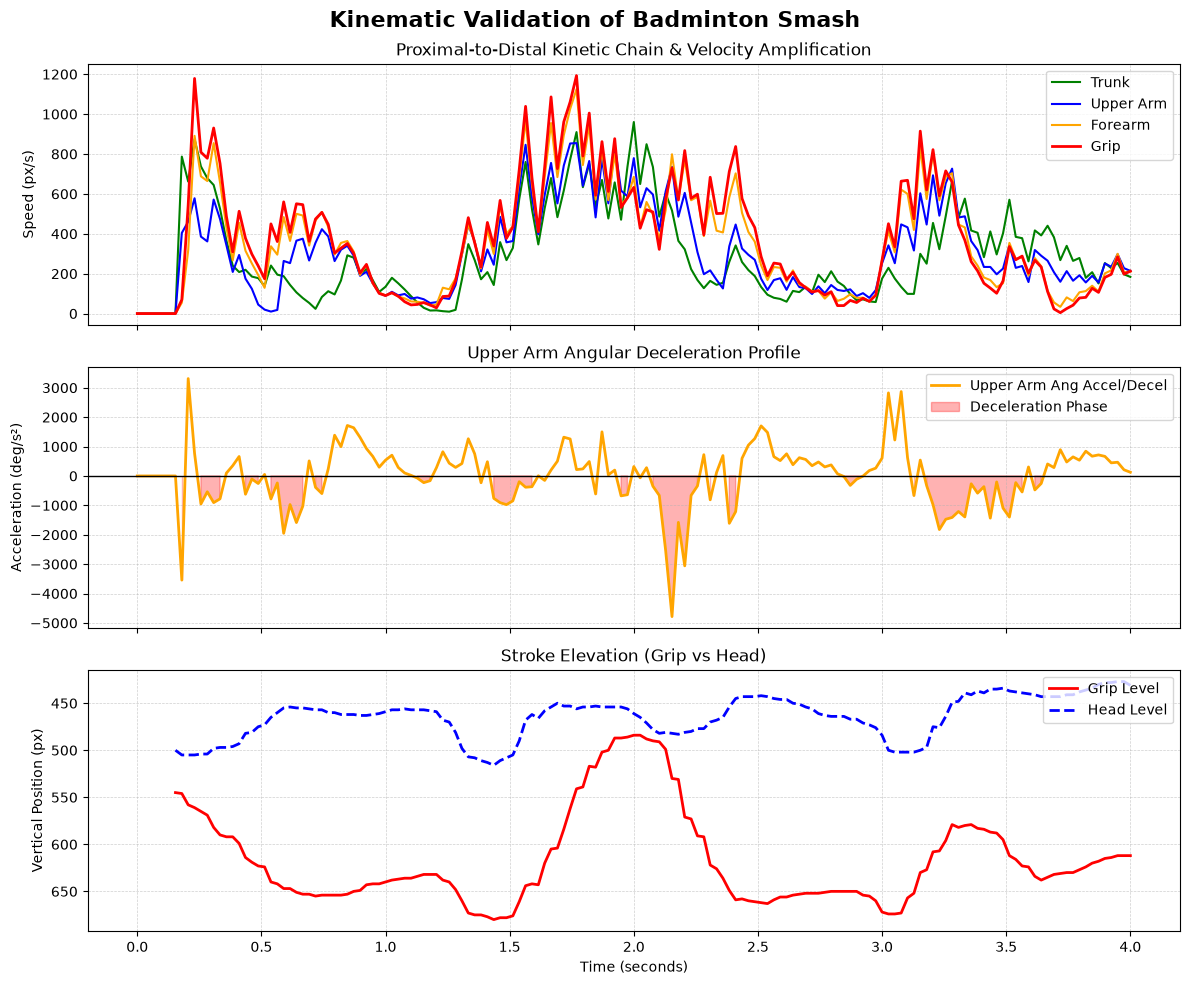

In [36]:
plot_smash_validation(metrics, fps)

In [ ]:
def find_smashes(input_video_path: str,
                 time_spans_included:list[tuple[float, float]],
                 time_spans_excluded:list[tuple[float, float]],
                 smash_entry:str='NOSE',
                 max_returning_time=0.5,
                 pre_smash_buffer=0.5,
                 post_smash_buffer=0.3) -> list[tuple[float, float]]:
    """
    Find smashes within time_spans_included and not overlapped with any time_spans_excluded
    * Find time points when RIGHT_INDEX is at peak positions higher than head
    * smash_time_spans = [[peak_time - pre_smash, peak_time + post_smash for peak_time in peak_times ]]

    max_returning_time (in seconds): the max time window from the peak angular velocity to exiting
    the smash_entry, for a over-head hit to be considered as a smash
    """

## Draw Overlaying Plot

In [ ]:
def draw_double_arrow(img, start_pt, end_pt, color, thickness=2):
    """
    Draws an arrow with a double-line shaft, mathematically matching
    the 'implies' symbol from the reference image.
    """
    p1 = np.array(start_pt, dtype=float)
    p2 = np.array(end_pt, dtype=float)

    vec = p2 - p1
    length = np.linalg.norm(vec)
    if length < 1e-3:
        return

    u = vec / length
    n = np.array([-u[1], u[0]])

    offset = 3.0
    tip_length = min(length * 0.35, 18.0)
    tip_width = 8.0

    if tip_width <= offset:
        tip_width = offset + 2.0

    intersect_dist = (offset * tip_length) / tip_width

    shaft_end_center = p2 - u * intersect_dist
    l1_end = shaft_end_center + n * offset
    l2_end = shaft_end_center - n * offset

    l1_start = p1 + n * offset
    l2_start = p1 - n * offset

    base_pt = p2 - u * tip_length
    wing1 = base_pt + n * tip_width
    wing2 = base_pt - n * tip_width

    cv2.line(img, (int(l1_start[0]), int(l1_start[1])), (int(l1_end[0]), int(l1_end[1])), color, thickness, cv2.LINE_AA)
    cv2.line(img, (int(l2_start[0]), int(l2_start[1])), (int(l2_end[0]), int(l2_end[1])), color, thickness, cv2.LINE_AA)

    cv2.line(img, (int(p2[0]), int(p2[1])), (int(wing1[0]), int(wing1[1])), color, thickness, cv2.LINE_AA)
    cv2.line(img, (int(p2[0]), int(p2[1])), (int(wing2[0]), int(wing2[1])), color, thickness, cv2.LINE_AA)


In [57]:

def overlay_kinetic_chain_linear_magnitude(input_video_path,
                                           output_video_path,
                                           metrics,
                                           scale_linear=0.08,
                                           scale_ang_accel=0.01,
                                           show_labels=False,
                                           pixels_per_meter=None,
                                           overwrite=True):

    if os.path.exists(output_video_path):
        if not overwrite:
            print(f"Skipping: Output file '{output_video_path}' already exists.")
            return
        else:
            print(f"Overwriting: Deleting existing file '{output_video_path}'...")
            os.remove(output_video_path)

    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print(f"Error: Could not open {input_video_path}")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0 or math.isnan(fps):
        fps = 120.0

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'avc1')
    out = cv2.VideoWriter(output_video_path, fourcc, int(fps), (width, height))

    divisor = 1.0 if pixels_per_meter is None else pixels_per_meter
    unit_v = "px/s" if pixels_per_meter is None else "m/s"
    fmt_v = "{:.0f}" if pixels_per_meter is None else "{:.2f}"

    # OpenCV uses BGR (Blue, Green, Red) format
    c_trunk = (0, 255, 0)       # Green
    c_upper_arm = (255, 0, 0)   # Blue
    c_accel = (0, 165, 255)     # Orange
    c_forearm = (0, 165, 255)   # Orange
    c_grip = (0, 0, 255)        # Red

    print("Rendering kinetic chain visual overlays...")
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or frame_idx >= len(metrics):
            break

        m = metrics[frame_idx]

        # 1. TRUNK
        if m.trunk_coord and m.trunk_speed > 20:
            start_pt = m.trunk_coord
            end_pt = (int(start_pt[0] + m.trunk_v[0] * scale_linear),
                      int(start_pt[1] + m.trunk_v[1] * scale_linear))
            cv2.arrowedLine(frame, start_pt, end_pt, c_trunk, 3, tipLength=0.25)
            cv2.circle(frame, start_pt, 5, (0, 0, 255), -1)
            if show_labels:
                cv2.putText(frame, f"Trunk: {fmt_v.format(m.trunk_speed / divisor)} {unit_v}",
                            (start_pt[0] + 15, start_pt[1] + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, c_trunk, 2, cv2.LINE_AA)

        # 2. UPPER ARM
        if m.elbow_coord and m.shoulder_coord:
            start_pt = m.elbow_coord

            if m.elbow_speed > 30:
                end_pt_vel = (int(start_pt[0] + m.elbow_v[0] * scale_linear),
                              int(start_pt[1] + m.elbow_v[1] * scale_linear))
                cv2.arrowedLine(frame, start_pt, end_pt_vel, c_upper_arm, 3, tipLength=0.25)

                ang_accel = m.upper_arm_angular_deceleration
                dx = m.elbow_coord[0] - m.shoulder_coord[0]
                dy = m.elbow_coord[1] - m.shoulder_coord[1]
                arm_length = math.hypot(dx, dy)

                if arm_length > 0:
                    perp_dx, perp_dy = -dy / arm_length, dx / arm_length
                    visual_ax = perp_dx * ang_accel * scale_ang_accel
                    visual_ay = perp_dy * ang_accel * scale_ang_accel
                    end_pt_accel = (int(start_pt[0] + visual_ax), int(start_pt[1] + visual_ay))
                    draw_double_arrow(frame, start_pt, end_pt_accel, c_accel, thickness=2)

                cv2.circle(frame, start_pt, 5, (0, 0, 255), -1)
                if show_labels:
                    cv2.putText(frame, f"Upper Arm: {fmt_v.format(m.elbow_speed / divisor)} {unit_v}",
                                (start_pt[0] + 15, start_pt[1] - 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, c_upper_arm, 2, cv2.LINE_AA)
                    cv2.putText(frame, f"Accel: {int(ang_accel)} deg/s^2",
                                (start_pt[0] + 15, start_pt[1] - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, c_accel, 1, cv2.LINE_AA)

        # 3. FOREARM
        if m.wrist_coord and m.wrist_speed > 40:
            start_pt = m.wrist_coord
            end_pt = (int(start_pt[0] + m.wrist_v[0] * scale_linear),
                      int(start_pt[1] + m.wrist_v[1] * scale_linear))
            cv2.arrowedLine(frame, start_pt, end_pt, c_forearm, 3, tipLength=0.25)
            cv2.circle(frame, start_pt, 5, (0, 0, 255), -1)
            if show_labels:
                cv2.putText(frame, f"Forearm: {fmt_v.format(m.wrist_speed / divisor)} {unit_v}",
                            (start_pt[0] + 15, start_pt[1] - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, c_forearm, 2, cv2.LINE_AA)

        # 4. GRIP
        if m.grip_coord and m.grip_speed > 50:
            start_pt = m.grip_coord
            end_pt = (int(start_pt[0] + m.grip_v[0] * scale_linear),
                      int(start_pt[1] + m.grip_v[1] * scale_linear))
            cv2.arrowedLine(frame, start_pt, end_pt, c_grip, 3, tipLength=0.25)
            cv2.circle(frame, start_pt, 5, (0, 0, 255), -1)
            if show_labels:
                cv2.putText(frame, f"Racket Grip: {fmt_v.format(m.grip_speed / divisor)} {unit_v}",
                            (start_pt[0] + 15, start_pt[1] - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, c_grip, 2, cv2.LINE_AA)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    print(f"Success! Saved to {output_video_path}")

In [60]:
# A standard adult badminton racket is exactly 0.68 meter long.
# pixels_per_meter can be calculated when the racket is flat.

overlay_kinetic_chain_linear_magnitude(
    input_video_path=input_video,
    output_video_path=output_video,
    metrics=metrics,
    scale_linear=0.2,
    scale_ang_accel=0.05,
    show_labels=True,
    # pixels_per_meter=120
)

Overwriting: Deleting existing file 'badminton-smash-1_analyzed.mp4'...
Rendering kinetic chain visual overlays...
Success! Saved to badminton-smash-1_analyzed.mp4


2026-09-20 21:33:23.615 python[41149:31564627] WARNING: -finishWriting should not be called on the main thread.


In [ ]:
# todo: draw overlapped speed vs. time